Iteration   0 | Best Fitness: 1.135968 | Best Position: [ 0.6419675  -0.85079123]
Iteration  10 | Best Fitness: 0.001119 | Best Position: [0.00422215 0.03318313]
Iteration  20 | Best Fitness: 0.000002 | Best Position: [ 0.00022932 -0.00154296]
Iteration  30 | Best Fitness: 0.000000 | Best Position: [-0.0001079  -0.00027178]
Iteration  40 | Best Fitness: 0.000000 | Best Position: [-6.67542545e-06  2.02240326e-05]
Iteration  50 | Best Fitness: 0.000000 | Best Position: [ 1.20189569e-06 -7.44472220e-07]
Iteration  60 | Best Fitness: 0.000000 | Best Position: [-1.08695762e-07 -5.74209299e-08]
Iteration  70 | Best Fitness: 0.000000 | Best Position: [ 8.09357143e-09 -1.58414658e-09]
Iteration  80 | Best Fitness: 0.000000 | Best Position: [-7.10540965e-10 -4.41850596e-10]
Iteration  90 | Best Fitness: 0.000000 | Best Position: [-4.28861787e-11 -2.47952890e-11]
Iteration  99 | Best Fitness: 0.000000 | Best Position: [-4.13573421e-12 -4.06407594e-12]

Final Result:
Best Position: [-4.13573421e-

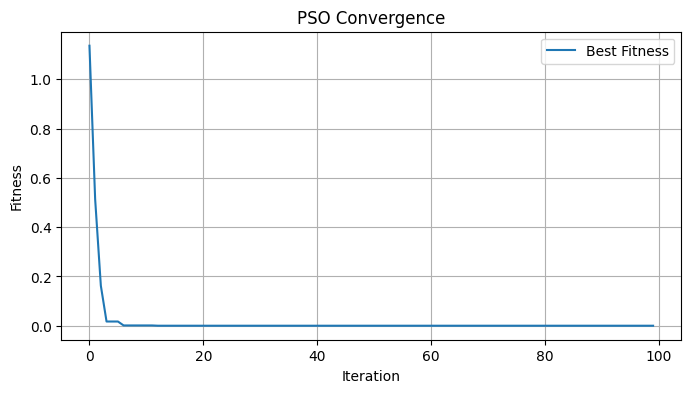

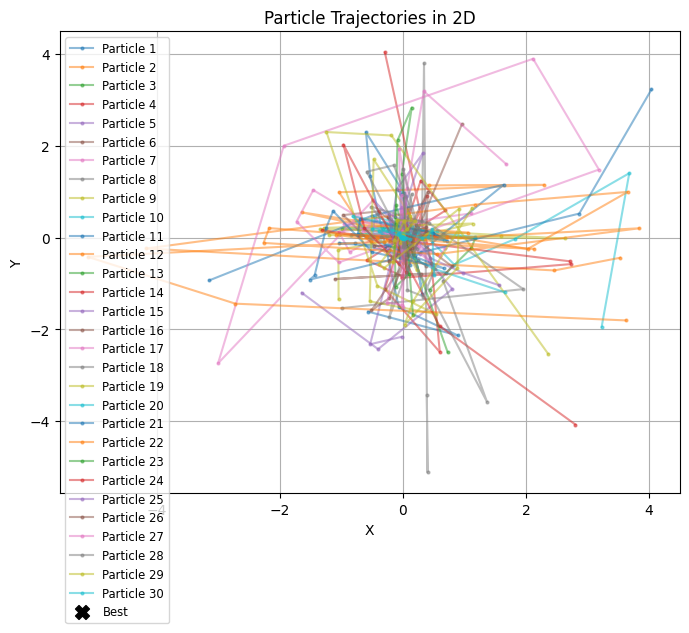

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Particle:
    def __init__(self, bounds, num_dimensions):
        self.position = np.random.uniform(bounds[0], bounds[1], num_dimensions)
        self.velocity = np.random.uniform(-1, 1, num_dimensions)
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')

class PSO:
    def __init__(self, objective_func, num_particles, num_dimensions, bounds, max_iterations, w=0.5, c1=1.0, c2=2.0):
        self.objective_func = objective_func
        self.num_particles = num_particles
        self.num_dimensions = num_dimensions
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.particles = [Particle(bounds, num_dimensions) for _ in range(num_particles)]
        self.global_best_position = np.zeros(num_dimensions)
        self.global_best_fitness = float('inf')
        self.history = []
        self.position_history = []  # Track positions for plotting

    def optimize(self, verbose=True):
        for iteration in range(self.max_iterations):
            iteration_positions = []

            for particle in self.particles:
                fitness = self.objective_func(particle.position)
                if fitness < particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position.copy()
                if fitness < self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_position = particle.position.copy()

            for particle in self.particles:
                r1 = np.random.rand(self.num_dimensions)
                r2 = np.random.rand(self.num_dimensions)
                cognitive = self.c1 * r1 * (particle.best_position - particle.position)
                social = self.c2 * r2 * (self.global_best_position - particle.position)
                particle.velocity = self.w * particle.velocity + cognitive + social
                particle.position += particle.velocity
                particle.position = np.clip(particle.position, self.bounds[0], self.bounds[1])
                iteration_positions.append(particle.position.copy())

            self.position_history.append(iteration_positions)
            self.history.append(self.global_best_fitness)

            if verbose and (iteration % 10 == 0 or iteration == self.max_iterations - 1):
                print(f"Iteration {iteration:3d} | Best Fitness: {self.global_best_fitness:.6f} | Best Position: {self.global_best_position}")

        return self.global_best_position, self.global_best_fitness

    def plot_convergence(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("PSO Convergence")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_particle_movement(self):
        if self.num_dimensions != 2:
            print("Particle movement plot is only available for 2D problems.")
            return

        plt.figure(figsize=(8, 6))
        for i in range(self.num_particles):
            trajectory = np.array([pos[i] for pos in self.position_history])
            plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=f'Particle {i+1}', alpha=0.5)
            plt.scatter(trajectory[-1, 0], trajectory[-1, 1], c='red', s=30)  # final position

        plt.scatter(self.global_best_position[0], self.global_best_position[1], c='black', marker='X', s=100, label='Best')
        plt.title("Particle Trajectories in 2D")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.legend(loc="best", fontsize="small")
        plt.show()

# === USAGE ===
if __name__ == "__main__":
    def custom_function(x):
        return np.sum(x**2)  # Sphere function (minimum at [0, 0])

    num_particles = 30
    num_dimensions = 2  # Must be 2 for plotting movement
    bounds = (-5.12, 5.12)
    max_iterations = 100

    pso = PSO(custom_function, num_particles, num_dimensions, bounds, max_iterations)
    best_position, best_fitness = pso.optimize()

    print("\nFinal Result:")
    print(f"Best Position: {best_position}")
    print(f"Best Fitness: {best_fitness:.6f}")

    pso.plot_convergence()
    pso.plot_particle_movement()
